In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")

In [2]:
import pandas as pd
import IONData
iondata = IONData.IONData()
def loadClusterCSV(filename,cluster=None):
    neurons = pd.read_csv(filename)
    neuronsArray= neurons.to_numpy()
    neuronScene=[]
    for neuron in neuronsArray:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['cluster'] = neuron[1]
        neurondict['sampleid'] = str(neuron[2])[0:6]
        neurondict['name']=str(neuron[2])[6:]+'.swc'
        if cluster ==neuron[1] or cluster ==None:
            neuronScene.append(neurondict)
    return neuronScene


neuronScene = loadClusterCSV("../resource/cluster_eachNeuron/cluster_eachNeuron_PB.csv")

leftNeurons=[]
rightNeurons=[]
for neuron in neuronScene:
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    somaz = property['somapoint'][2]
    if somaz>5700:
        neuron['lateral']='right'
        rightNeurons.append(neuron)
    else:
        neuron['lateral']='left'
        leftNeurons.append(neuron)
    neuron['property']=property



In [4]:
import Visual as nv

neuronvis = nv.neuronVis()
neuronvis.render.setBackgroundColor((1.0,1.00,1.0,1.0))

# for neuron in neuronScene:
for neuron in neuronScene:
    if neuron['cluster']==8:
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        neuronvis.addNeuronTree(neuronT,'200313-083.swc',somaColor=[0,1,0],axonColor=[1,0,0],dendriteColor=[0,0,1])
        # break
neuronvis.render.savepng('../resource/pbncluster8.png')
neuronvis.render.closeWindow()

# neuronvis.render.run()



In [3]:
import numpy as np 
import seaborn	as sns
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

regions=['SI','MSC','VM','VP','SPF','IMD','MD','RE','CM','PCN','CL','PF','LHA','LPO','PSTN','RCH','ZI','SNr','VTA','MRN','SCm','PAG','CUN','PPN','DR','PSV','PB','SOC','PRNc','SUT','P5','LC','PRNr','MY-sen','CU','NTS','VII','GRN','IRN','LRN','MARN','MDRN','PARN','PGRN','MV','ANcr2','COPY','PFL']


In [4]:
import BrainRegion as BR 
br = BR.BrainRegion()
br.praseJson()

neuronScenedf = pd.DataFrame(neuronScene)
def getRegionProject(Neurons,regions):
    clusterProject={}
    for neuron in Neurons:
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(property['projectregion'])
        brpropertyLeft.setProperty(property['projectleftregion'])
        brpropertyRight.setProperty(property['projectrightregion'])

        regionProject=[]
        for region in regions:
                regionsum = brproperty.getSumProperty(region)
                regionProject.append(regionsum)
        if neuron['cluster'] not in clusterProject.keys():
            clusterProject[neuron['cluster']]=np.array(regionProject).astype(np.float64)
        else:
            clusterProject[neuron['cluster']]+=np.array(regionProject).astype(np.float64)
    return clusterProject
clusterProjectLeft = getRegionProject(leftNeurons,regions)
clusterProjectRight = getRegionProject(rightNeurons,regions)
for key in clusterProjectLeft.keys():
    clusterProjectLeft[key]/=(neuronScenedf.cluster==key).sum()

for key in clusterProjectRight.keys():
    clusterProjectRight[key]/=(neuronScenedf.cluster==key).sum()

In [1]:

fig,ax = plt.subplots(figsize=(13,13))
ax0 = plt.subplot(1,2,1)
keys=list(clusterProjectLeft.keys())

data = []
for key in sorted(keys):
    data.append(clusterProjectRight[key])
mat = np.array(data).T
mat = np.log2(mat/1000.0+1)
sns.heatmap(mat)
plt.xticks([index+0.5 for index in range(len(keys))],tuple(sorted(keys)),fontsize=20)
plt.yticks([index+0.5 for index in range(len(regions))],tuple(regions),rotation = 0,fontsize=15)

# clusterProjectLeft

ax1= plt.subplot(1,2,2)
keys=list(clusterProjectRight.keys())
print(clusterProjectRight.keys())
data = []
for key in sorted(keys):
    data.append(clusterProjectRight[key])
mat = np.array(data).T
mat = np.log2(mat/1000.0+1)
cg= sns.heatmap(mat)
# cg= sns.heatmap(np.array(data).T)
# plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), size=20)
plt.xticks([index+0.5 for index in range(len(keys))],tuple(sorted(keys)),fontsize=20)
plt.yticks([index+0.5 for index in range(len(regions))],tuple(regions),rotation = 0,fontsize=15)

NameError: name 'plt' is not defined

In [6]:
clusterProjectLeft

{6: array([ 556.05766294,    0.        ,  169.00877381,    0.        ,
          49.48651506,    0.        ,    0.        ,   12.39259625,
           0.        ,    0.        ,    0.        ,    0.        ,
         774.39904787,   25.472332  ,  119.76826475,    0.        ,
         607.3529635 ,  283.6189575 ,   16.98977469, 1226.08996581,
          47.69540744,  991.59886175,   46.79280856,   96.30331994,
           0.        ,    0.        ,  425.92080687,    0.        ,
          98.30664062,    0.        ,    0.        ,    0.        ,
         118.21015169,  176.04172088,    0.        ,    0.        ,
           0.        ,   29.37467575,    0.        ,   12.87283994,
           0.        ,    5.81284569,    1.855324  ,    3.14221956,
          58.0826645 ,    0.        ,    0.        ,    0.        ]),
 7: array([  71.78417879,   48.82798497,  598.57883588,  503.51136421,
         168.82359579,  177.19033856, 1212.40011776,   66.36890412,
         141.41995868,  181.46294424,   

In [8]:
clusterProjectRight

{10: array([   83.06017112,     0.        ,   364.5946665 ,   147.93049769,
          230.14273063,   244.68954087,  1038.76771931,    75.25666806,
          136.05858231,    62.38235469,    20.9471245 ,   347.25048831,
          770.01556012,     0.        ,   482.17174625,     0.        ,
          457.62782156,   948.81034275,   693.06316369,  6622.14100256,
        10301.76562356,  3494.44826713,  1003.39460519,  2541.07613662,
          180.05488394,   350.81300356,  2334.96802519,     0.        ,
          336.33306887,   133.38412569,    25.15821031,     0.        ,
          649.72300144,    26.83559606,     0.        ,     0.        ,
            0.        ,   231.30838012,   244.85386275,     0.        ,
            0.        ,     0.        ,   246.56740569,    59.15791513,
           20.44691656,     0.        ,     0.        ,     0.        ]),
 6: array([3.47042563e+03, 1.03501301e+02, 1.07159355e+03, 8.84414958e+02,
        5.98750326e+01, 7.55183426e+02, 1.63425753e+03,

<AxesSubplot:>

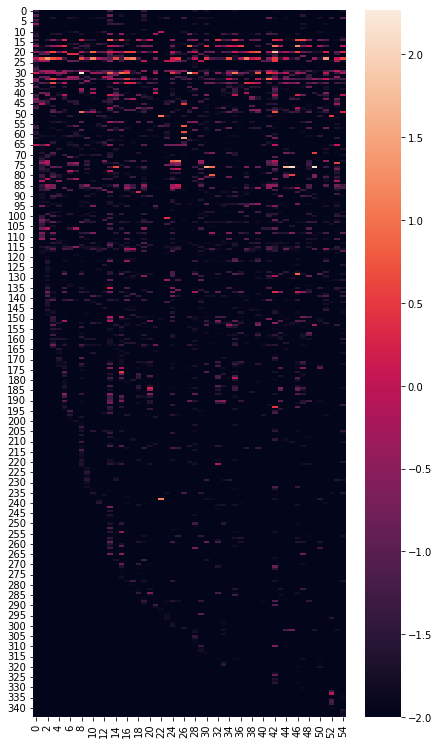

In [54]:
leftdf = iondata.getPropertiesDF(leftNeurons)
projectregiondf= leftdf[leftdf.property.str.contains('projectregion',case=False)]
projectregiondf.set_index(['property'],inplace=True)

data =projectregiondf.to_numpy().astype(np.float16)
data=(np.log2(data/10000.0+0.25))
fig,ax = plt.subplots(figsize=(7,13))

sns.heatmap(data)